# 03 · Topology gallery — the range of shapes the engine handles

A scenario is a **validated directed acyclic graph of typed nodes**: factories produce,
intermediate shops hold inventory and route orders across suppliers, and demand sinks are
the only source of new cash. The same `Runner` drives *any* well-formed DAG.

This notebook is a guided tour of that range. We build, **draw**, **run**, and **compare**
five structurally distinct topologies:

| # | shape | how |
|---|---|---|
| 1 | **Linear chain** | load `setups/three_node_chain` (factory → shop → sink) |
| 2 | **Supplier contention** | load `setups/two_factories_two_shops` (2 factories feed 2 shops) |
| 3 | **Fan-out** | scaffold one-factory-per-product across 3 shops at runtime |
| 4 | **Deeper / wider** | a larger catalog scaffolded across more shops |
| 5 | **Lateral cross-stocking** | a peer `intermediate → intermediate` edge (a hub feeds a satellite) |

Topologies 3–5 are built **at runtime** by assembling a setup directory under
`data/notebook_demos/03/` and `load_setup`-ing it — exactly how a modeller would, no API key.

> Topology 5 is the headline new shape: a **lateral** supplier link (`intermediate →
> intermediate`) that earlier engine versions rejected. Validation is now **type-based** —
> any factory/intermediate may sell to any intermediate/sink as long as the edge union stays
> acyclic — so peer warehouses can cross-stock.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths resolve.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## The drawing helper

We reuse the `draw_topology` from notebook **00**: rebuild the structural `Graph`, compute
the **display level** of each node (0 = factory, increasing toward the sinks via longest
path), and lay nodes out left-to-right by level, coloured by node type. `compute_levels` is
now a **display-only** hint — the engine no longer schedules by echelon level (it walks the
graph demand-pull, sinks first), so a node's level carries no functional meaning. For a
lateral link it just places the peer warehouse one column to the right.

In [2]:
import networkx as nx
from src.sim.graph import build_graph, compute_levels

def draw_topology(scenario, ax=None, title=""):
    node_ids = [ni.node.id for ni in scenario.nodes]
    graph = build_graph(node_ids, scenario.edges)
    levels = compute_levels(graph)
    ntype = {ni.node.id: type(ni.node).__name__ for ni in scenario.nodes}

    G = nx.DiGraph()
    for nid in node_ids:
        G.add_node(nid, subset=levels[nid])
    for e in scenario.edges:
        G.add_edge(e.supplier_id, e.buyer_id)

    pos = nx.multipartite_layout(G, subset_key="subset")
    color = {"FactoryNode": "#4C72B0", "IntermediateNode": "#55A868", "DemandSinkNode": "#C44E52"}
    colors = [color.get(ntype[n], "#888") for n in G.nodes]

    ax = ax or plt.gca()
    nx.draw_networkx(G, pos, ax=ax, node_color=colors, node_size=1100,
                     font_size=6, font_color="white", arrowsize=12,
                     edgecolors="black", linewidths=0.5)
    ax.set_title(title or "supply-chain DAG"); ax.axis("off")
    return levels

## A consistent KPI definition

We score every topology with the same three numbers, computed from the tidy
`node_timeseries_df` (cols: `tick, node_id, node_type, region, level, cash, inventory_total, ...`):

- **cash growth** — total final node cash ÷ total initial node cash (the system makes money
  only when sinks pay shops, so >1 means the chain is net-profitable).
- **shop availability** — fraction of (shop × tick) observations where `inventory_total > 0`
  (a simple service / on-shelf proxy).
- **mean shop inventory** — average `inventory_total` held across all shop nodes and ticks.

In [3]:
from src.sim.runner import Runner
from src.sim.inspect import node_timeseries_df

def run_and_score(scenario, name):
    run_log = Runner(scenario).run()
    ts = node_timeseries_df(run_log, scenario)

    by_tick = ts.sort_values("tick").groupby("node_id")
    init_cash = by_tick["cash"].first().sum()
    final_cash = by_tick["cash"].last().sum()
    cash_growth = final_cash / init_cash if init_cash else float("nan")

    shops = ts[ts["node_type"] == "IntermediateNode"]
    availability = (shops["inventory_total"] > 0).mean() if len(shops) else float("nan")
    mean_shop_inv = shops["inventory_total"].mean() if len(shops) else float("nan")

    n_fac = (scenario.nodes_df()["node_type"] == "FactoryNode").sum()
    n_shop = (scenario.nodes_df()["node_type"] == "IntermediateNode").sum()
    n_sink = (scenario.nodes_df()["node_type"] == "DemandSinkNode").sum()

    return {
        "topology": name,
        "nodes": len(scenario.nodes),
        "factories": int(n_fac),
        "shops": int(n_shop),
        "sinks": int(n_sink),
        "products": len(scenario.catalog),
        "cash_growth": round(cash_growth, 3),
        "shop_availability": round(float(availability), 3),
        "mean_shop_inv": round(float(mean_shop_inv), 1),
    }, ts, run_log

## A runtime setup builder

The committed setups are tiny, so for the fan-out shapes we build new ones on disk and load
them back. The recipe (see notebook 00 for the API):

1. Read the base `three_node_chain/setup.yaml` to inherit valid `run:`, `market:`, `disruption:` blocks.
2. Build a catalog and write `catalog.csv` ourselves (the column order `load_setup` expects).
3. Get a `nodes:`/`edges:` block from `scaffold_topology(catalog, spec)`.
4. **Attach policies.** The scaffolder emits *topology only* — no `policy:` blocks — so we
   wire up the same textbook policies the committed setups use (factories produce, shops
   order-up-to, sinks demand). Without this every node defaults to a no-op and nothing flows.
5. Write `setup.yaml` = the base doc with `nodes`/`edges` swapped for our block, then `load_setup` it.

In [4]:
import csv
import yaml
from src.sim.setup_io import load_setup
from src.sim.topology_scaffolder import scaffold_topology, ScaffoldSpec

BASE_DOC = yaml.safe_load(Path("setups/three_node_chain/setup.yaml").read_text())
DEMO_ROOT = Path("data/notebook_demos/03")
DEMO_ROOT.mkdir(parents=True, exist_ok=True)

CATALOG_COLS = ["product_id", "name", "category", "base_price",
                "unit_cost", "seasonality", "related_products", "init_stock_share"]

def write_catalog_csv(path, wares):
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=CATALOG_COLS)
        w.writeheader()
        for ware in wares:
            w.writerow({
                "product_id": ware.product_id,
                "name": ware.name,
                "category": ware.category,
                "base_price": ware.base_price,
                "unit_cost": ware.unit_cost,
                "seasonality": ware.seasonality,
                "related_products": "",
                "init_stock_share": 1.0,
            })

def attach_policies(nodes):
    """`scaffold_topology` emits topology only — no `policy:` blocks, so every
    node would default to a no-op. We attach the same textbook policies the
    committed setups use: factories produce to a target, shops order-up-to a
    cover horizon, sinks generate demand. We also seed shops with a little
    starting inventory so they are not empty at tick 0."""
    for n in nodes:
        if n["type"] == "factory":
            n["inventory"] = 100
            n["policy"] = {"name": "static_factory", "params": {"target_inventory": 300}}
        elif n["type"] == "intermediate":
            n["inventory"] = {pid: 30 for pid in n.get("carried_products", [])}
            lp = next(iter(n.get("list_prices", {}).values()), 12.0)
            n["policy"] = {
                "name": "order_up_to",
                "params": {"cover_horizon_ticks": 14, "list_price_out": float(lp)},
            }
        elif n["type"] == "demand_sink":
            n["demand_dist"] = {"kind": "normal", "mean": 10.0, "std": 2.0}
            n["policy"] = {"name": "default_demand_sink", "params": {}}
    return nodes

def build_setup(name, catalog, spec):
    """Assemble + load a setup dir from a catalog and a ScaffoldSpec."""
    setup_dir = DEMO_ROOT / name
    setup_dir.mkdir(parents=True, exist_ok=True)
    write_catalog_csv(setup_dir / "catalog.csv", catalog)

    block = scaffold_topology(catalog, spec)
    doc = dict(BASE_DOC)              # inherit run/market/disruption
    doc["nodes"] = attach_policies(block["nodes"])
    doc["edges"] = block["edges"]
    (setup_dir / "setup.yaml").write_text(yaml.safe_dump(doc, sort_keys=False))

    sc = load_setup(str(setup_dir))
    print(f"{name}: loaded {len(sc.nodes)} nodes, {len(sc.edges)} edges, {len(sc.catalog)} products")
    return sc

## Topology 1 — Linear chain

The minimal example: `factory-1 → shop-1 → sink-1`, one product, 30 ticks. A single supply
path; nothing competes for anything.

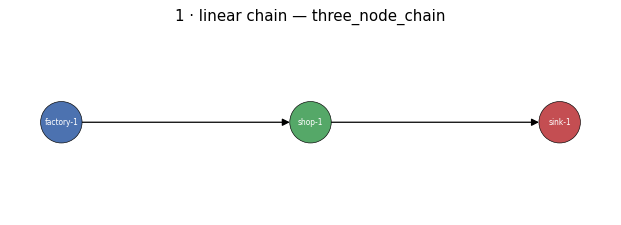

,node_id,node_type,region,init_seed,policy_class
0,factory-1,FactoryNode,US,3234706689,StaticFactoryPolicy
1,shop-1,IntermediateNode,US,98739437,OrderUpToPolicy
2,sink-1,DemandSinkNode,US,3754311622,DefaultDemandSinkPolicy


In [5]:
chain = load_setup("setups/three_node_chain")

fig, ax = plt.subplots(figsize=(7, 2.6))
draw_topology(chain, ax=ax, title="1 · linear chain — three_node_chain")
plt.tight_layout(); plt.show()
chain.nodes_df()

## Topology 2 — Supplier contention

`two_factories_two_shops`: two factories feed two shops on a shared product. Multiple supply
edges per buyer mean the shops **compete** for upstream inventory — the multi-supplier routing
in each shop's policy now matters.

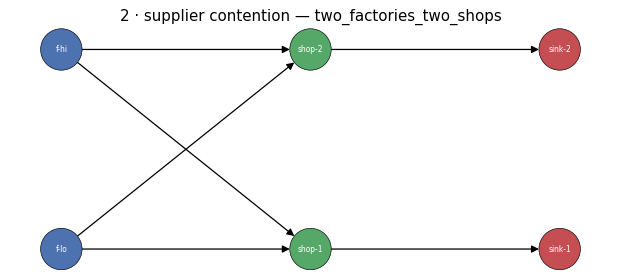

,node_id,node_type,region,init_seed,policy_class
0,f-lo,FactoryNode,US,3566192719,StaticFactoryPolicy
1,f-hi,FactoryNode,US,739400997,StaticFactoryPolicy
2,shop-1,IntermediateNode,US,98739437,OrderUpToPolicy
3,shop-2,IntermediateNode,US,820177096,OrderUpToPolicy
4,sink-1,DemandSinkNode,US,3754311622,DefaultDemandSinkPolicy
5,sink-2,DemandSinkNode,US,1623657135,DefaultDemandSinkPolicy


,supplier_id,buyer_id,default_lead_time
0,f-lo,shop-1,4
1,f-hi,shop-1,2
2,f-lo,shop-2,4
3,f-hi,shop-2,2
4,shop-1,sink-1,1
5,shop-2,sink-2,1


In [6]:
contention = load_setup("setups/two_factories_two_shops")

fig, ax = plt.subplots(figsize=(7, 3.2))
draw_topology(contention, ax=ax, title="2 · supplier contention — two_factories_two_shops")
plt.tight_layout(); plt.show()
display(contention.nodes_df())
contention.edges_df()

## Topology 3 — Fan-out

Now we go to runtime. Starting from a small multi-product catalog, `scaffold_topology`
emits **one factory per product** and spreads them across `shop_count=3` shops (round-robin),
with a dedicated sink per (product × shop). The result fans **wide**: many parallel chains
sharing the same stochastic world.

catalog product ids: ['P0000', 'P0001', 'P0002', 'P0003', 'P0004', 'P0005']
fan_out: loaded 15 nodes, 12 edges, 6 products


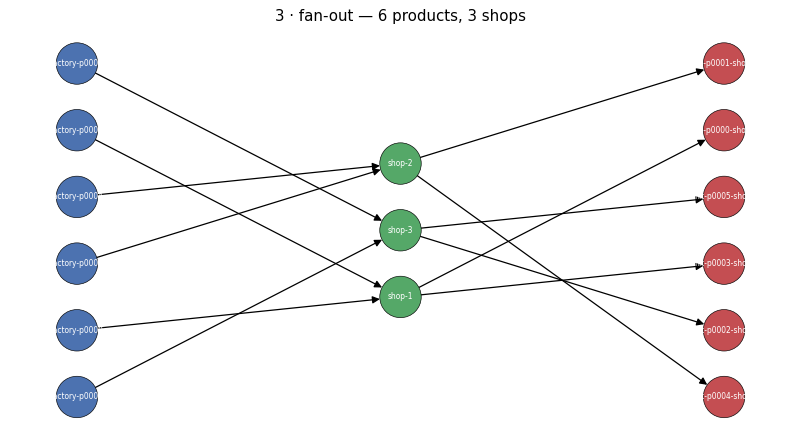

,node_id,node_type,region,init_seed,policy_class
0,factory-p0000,FactoryNode,US,2867960058,StaticFactoryPolicy
1,factory-p0001,FactoryNode,US,3589397633,StaticFactoryPolicy
2,factory-p0002,FactoryNode,US,15867996,StaticFactoryPolicy
3,factory-p0003,FactoryNode,US,737305571,StaticFactoryPolicy
4,factory-p0004,FactoryNode,US,1458743230,StaticFactoryPolicy
5,factory-p0005,FactoryNode,US,2180180805,StaticFactoryPolicy
6,shop-1,IntermediateNode,US,98739437,OrderUpToPolicy
7,shop-2,IntermediateNode,US,820177096,OrderUpToPolicy
8,shop-3,IntermediateNode,US,1541614671,OrderUpToPolicy
9,sink-p0000-shop-1,DemandSinkNode,US,3942531750,DefaultDemandSinkPolicy


In [7]:
from src.tuning import make_synthetic_catalog

# A 6-product catalog -> 6 factories, spread across 3 shops.
catalog6 = make_synthetic_catalog(6)
print("catalog product ids:", [w.product_id for w in catalog6])

fanout = build_setup(
    "fan_out",
    catalog6,
    ScaffoldSpec(shop_count=3, factory_capacity=120, shop_capacity=400, factory_lead_time=2),
)

fig, ax = plt.subplots(figsize=(9, 5))
draw_topology(fanout, ax=ax, title="3 · fan-out — 6 products, 3 shops")
plt.tight_layout(); plt.show()
fanout.nodes_df()

## Topology 4 — Deeper / wider

A structurally larger shape: a **12-product** catalog scaffolded across **5 shops**, with a
bigger factory capacity. Many more nodes and far more factory→shop and shop→sink edges than
anything above — a stress test that the engine handles arbitrary fan-out without special-casing.

wide: loaded 29 nodes, 24 edges, 12 products


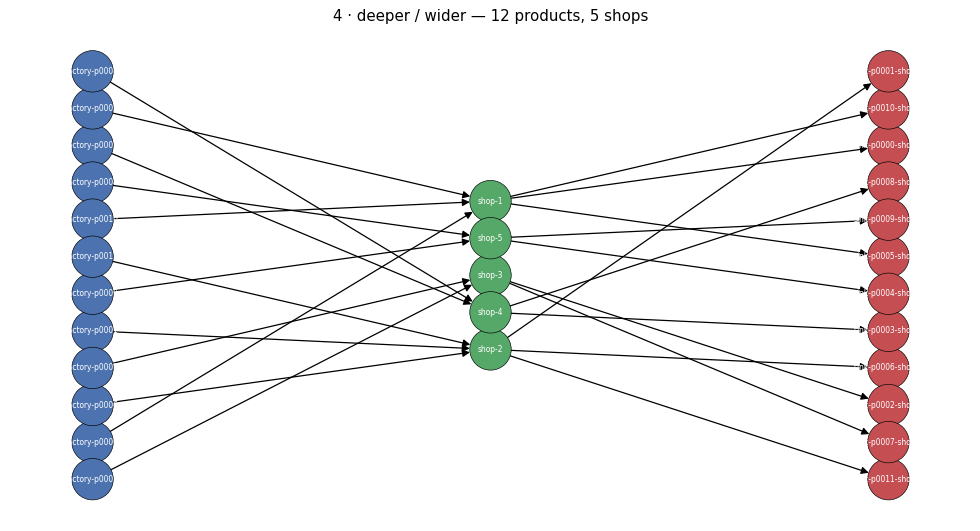

,0
n_steps,30
start_date,2024-01-01 00:00:00
world_seed,42
n_products,12
n_nodes,29
n_DemandSinkNode,12
n_FactoryNode,12
n_IntermediateNode,5


In [8]:
catalog12 = make_synthetic_catalog(12)

wide = build_setup(
    "wide",
    catalog12,
    ScaffoldSpec(shop_count=5, factory_capacity=160, shop_capacity=500, factory_lead_time=2),
)

fig, ax = plt.subplots(figsize=(11, 6))
draw_topology(wide, ax=ax, title="4 · deeper / wider — 12 products, 5 shops")
plt.tight_layout(); plt.show()
wide.summary_df().T

## Topology 5 — Lateral cross-stocking (a peer warehouse link)

Every shape so far flows strictly **downward**: factory → shop → sink. This one adds a
**lateral** edge — an `intermediate → intermediate` link, where one warehouse buys from a
*peer* warehouse at the same depth. That shape was **rejected** under the old echelon-level
validation (same-level links were illegal); it is now legal, validated purely by node *type*
(supplier ∈ {factory, intermediate}, buyer ∈ {intermediate, sink}).

We model a **regional hub** that stocks from the factory on a fast lane, and a **satellite**
store that can source either from the factory directly (a long, slow lane) *or* laterally
from the hub (a short cross-stock lane). The satellite's order-up-to policy splits
cheapest-first across both — so the hub doubles as a fast local supplier for its peer.

The scaffolder only emits factory→shop→sink edges, so we author this `nodes`/`edges` block
by hand and `load_setup` it — same recipe as above, just with one extra edge.

lateral: loaded 5 nodes, 5 edges, 1 products
lateral edge present: True


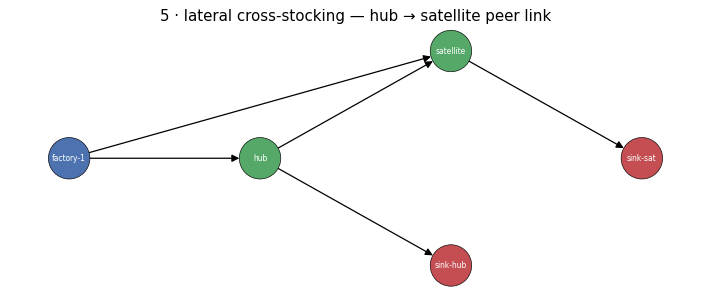

,supplier_id,buyer_id,default_lead_time
0,factory-1,hub,3
1,factory-1,satellite,5
2,hub,satellite,1
3,hub,sink-hub,1
4,satellite,sink-sat,1


In [9]:
def _shop(node_id, inv):
    return {
        "id": node_id, "type": "intermediate", "region": "US",
        "carried_products": ["P0000"], "capacity": 400, "tags": ["shop"],
        "inventory": {"P0000": inv}, "list_prices": {"P0000": 12.0},
        "min_order_imposed": {"P0000": 0}, "cash": 1000.0,
        "policy": {"name": "order_up_to", "params": {
            "cover_horizon_ticks": 14, "safety_lead_pct_of_lag": 0.333,
            "delivery_lag": 3, "unit_cost": 5.0, "list_price_out": 12.0}},
    }

def _sink(node_id):
    return {
        "id": node_id, "type": "demand_sink", "region": "US", "product_id": "P0000",
        "demand_dist": {"kind": "normal", "mean": 12.0, "std": 3.0},
        "income_rate": 300.0, "cash": 1000.0,
        "policy": {"name": "default_demand_sink", "params": {}},
    }

def build_lateral_setup():
    setup_dir = DEMO_ROOT / "lateral"
    setup_dir.mkdir(parents=True, exist_ok=True)
    # Single-product catalog authored directly (one row, P0000).
    write_catalog_csv(setup_dir / "catalog.csv", make_synthetic_catalog(1))

    nodes = [
        {"id": "factory-1", "type": "factory", "region": "US",
         "produces_product_id": "P0000", "unit_cost": 5.0, "capacity_per_tick": 80,
         "inventory": 100, "list_price": 5.0, "cash": 0.0,
         "policy": {"name": "static_factory", "params": {"target_inventory": 400}}},
        _shop("hub", inv=80),
        _shop("satellite", inv=40),
        _sink("sink-hub"),
        _sink("sink-sat"),
    ]
    edges = [
        {"supplier": "factory-1", "buyer": "hub",       "lead_time": 3},  # fast factory lane
        {"supplier": "factory-1", "buyer": "satellite", "lead_time": 5},  # slow direct lane
        {"supplier": "hub",       "buyer": "satellite", "lead_time": 1},  # LATERAL cross-stock
        {"supplier": "hub",       "buyer": "sink-hub",  "lead_time": 1},
        {"supplier": "satellite", "buyer": "sink-sat",  "lead_time": 1},
    ]
    doc = dict(BASE_DOC)
    doc["nodes"] = nodes
    doc["edges"] = edges
    (setup_dir / "setup.yaml").write_text(yaml.safe_dump(doc, sort_keys=False))

    sc = load_setup(str(setup_dir))
    print(f"lateral: loaded {len(sc.nodes)} nodes, {len(sc.edges)} edges, {len(sc.catalog)} products")
    return sc

lateral = build_lateral_setup()
print("lateral edge present:",
      lateral.edges_df().query("supplier_id == 'hub' and buyer_id == 'satellite'").shape[0] == 1)

fig, ax = plt.subplots(figsize=(8, 3.4))
draw_topology(lateral, ax=ax, title="5 · lateral cross-stocking — hub → satellite peer link")
plt.tight_layout(); plt.show()
display(lateral.edges_df())

## Run & score every topology

Same `Runner`, same KPI definition, four different shapes.

In [10]:
topologies = [
    ("1 · linear chain", chain),
    ("2 · supplier contention", contention),
    ("3 · fan-out", fanout),
    ("4 · deeper / wider", wide),
    ("5 · lateral cross-stocking", lateral),
]

rows, runs = [], {}
for name, sc in topologies:
    kpis, ts, run_log = run_and_score(sc, name)
    rows.append(kpis)
    runs[name] = ts

summary = pd.DataFrame(rows).set_index("topology")
summary

,nodes,factories,shops,sinks,products,cash_growth,shop_availability,mean_shop_inv
topology,,,,,,,,
1 · linear chain,3,1,1,1,1,3.345,0.967,68.7
2 · supplier contention,6,2,2,2,1,13.314,0.979,109.8
3 · fan-out,15,6,3,6,6,2.065,1.000,133.1
4 · deeper / wider,29,12,5,12,12,3.497,0.993,174.3
5 · lateral cross-stocking,5,1,2,2,1,3.835,0.933,92.0


## Compare — KPI bar charts

Three panels, one per KPI, across all four topologies.

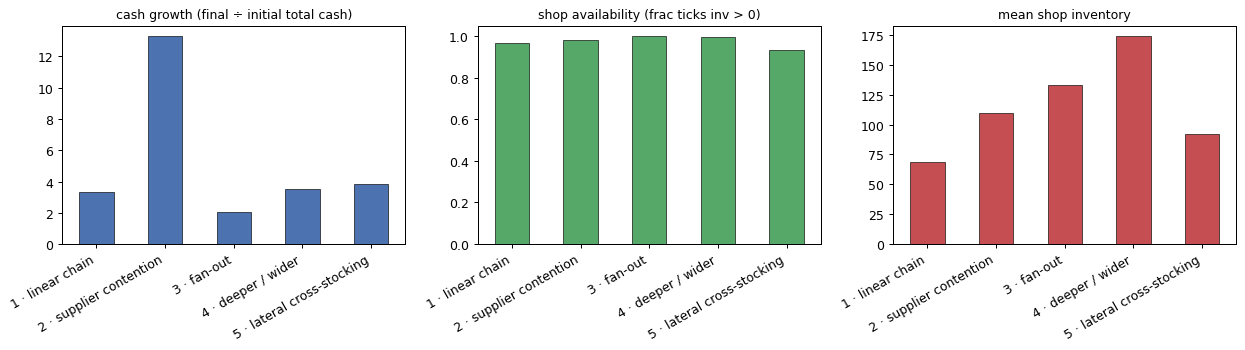

In [11]:
kpi_specs = [
    ("cash_growth", "cash growth (final ÷ initial total cash)", "#4C72B0"),
    ("shop_availability", "shop availability (frac ticks inv > 0)", "#55A868"),
    ("mean_shop_inv", "mean shop inventory", "#C44E52"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (col, label, c) in zip(axes, kpi_specs):
    summary[col].plot(kind="bar", ax=ax, color=c, edgecolor="black", linewidth=0.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=30)
    for lab in ax.get_xticklabels():
        lab.set_ha("right")
plt.tight_layout(); plt.show()

## Ranked summary

Ranked by cash growth — the bottom-line measure of whether a topology turns the same world
into profit.

In [12]:
ranked = summary.sort_values("cash_growth", ascending=False)
ranked[["nodes", "factories", "shops", "sinks", "products",
        "cash_growth", "shop_availability", "mean_shop_inv"]]

,nodes,factories,shops,sinks,products,cash_growth,shop_availability,mean_shop_inv
topology,,,,,,,,
2 · supplier contention,6,2,2,2,1,13.314,0.979,109.8
5 · lateral cross-stocking,5,1,2,2,1,3.835,0.933,92.0
4 · deeper / wider,29,12,5,12,12,3.497,0.993,174.3
1 · linear chain,3,1,1,1,1,3.345,0.967,68.7
3 · fan-out,15,6,3,6,6,2.065,1.000,133.1


## Takeaway

One `Runner`, five very different DAGs — a 3-node chain, a contention diamond, two
scaffolded fan-outs up to a dozen factories across five shops, and a lateral hub→satellite
cross-stock — all built, drawn, run and scored through the **same** API. Adding a shape is
just *more nodes and edges*: the engine never special-cases topology, which is exactly what
makes the project hackable. The lateral link in particular needs **no** new machinery —
it is just another edge that passes type-based validation.

The KPIs differ because structure differs. Wider fan-outs spread the same world's demand
across more parallel chains (changing per-shop inventory and availability), while cash growth
tracks how efficiently each shape converts sink income into profit. Next stop —
notebook **04** holds the *topology* fixed and varies the *policy* under Common Random Numbers.